
# Time series generation through Markov-switching Gaussian mixture modeling

In signal processing, any useful signal can often be represented as the response obtained by passing **white noise** through a learnable dynamical system. A classical **Gaussian mixture model (GMM)** can approximate multi-modal marginal distributions, but a static i.i.d. GMM treats every time point independently and therefore cannot capture temporal dependence.

The **Markov-switching Gaussian mixture** model used in S2Generator resolves this limitation by introducing a latent regime $S_t$ that evolves as a first-order Markov chain. Conditional on the current regime, the observation is generated by a Gaussian emission driven by fresh white noise:

$$
S_t \sim \mathrm{Markov}(S_{t-1}), \qquad y_t = \mu_{S_t} + \sigma_{S_t}\, w_t, \quad w_t \sim \mathcal{N}(0, 1).
$$

Compared with the ARIMA, Wiener-filter, Kalman-filter, and MSAR simulators in S2Generator, the `GaussianMixtureSimulator` is particularly suitable for **segment-like** or **mixture-distributed** time series whose mean and variance change across persistent regimes, while preserving the same `fit` / `transform` interface.

This notebook introduces the method in the following order:

1. Elaboration of the basic mathematical principles.
2. Construction and fitting of a Markov-switching Gaussian model from input data.
3. Generation of new sequences by simulating regime paths and white-noise excitations.
4. Visualization and statistical comparison with the input sequence.
5. Usage of the encapsulated `GaussianMixtureSimulator` in S2Generator.



## Markov-switching Gaussian mixture model

Let $y_t$ denote the observed time series and $S_t \in \{0, 1, \ldots, K-1\}$ the unobserved regime indicator at time $t$. A first-order Markov-switching Gaussian model can be written as:
$$
y_t = \mu_{S_t} + \sigma_{S_t}\, w_t, \quad w_t \sim \mathcal{N}(0, 1). \quad (1)
$$

The latent regime evolves as a first-order Markov chain:
$$
P(S_t = j \mid S_{t-1} = i) = P_{ij}, \quad \sum_{j=0}^{K-1} P_{ij} = 1. \quad (2)
$$

Thus the overall generating mechanism contains **two random excitations**:

1. **Discrete Markov switching**: determines which Gaussian component is active at each time step;
2. **Continuous standard white noise** $w_t$: drives the Gaussian emission within each regime.

### Why this is different from a static GMM

A static GMM models only the marginal distribution
$$
p(y) = \sum_{k=0}^{K-1} \pi_k \, \mathcal{N}(y \mid \mu_k, \sigma_k^2),
$$
and generates i.i.d. samples by independently drawing both the component index and the Gaussian value at every time point. That destroys temporal structure.

By contrast, the Markov-switching formulation keeps the **mixture interpretation** while adding **regime persistence** through equation (2). Generated sequences therefore exhibit segment-like behavior: consecutive observations tend to remain in the same regime before switching.

### White-noise-to-signal viewpoint

The model can be summarized as:
$$
\text{Markov chain } S_t \;\Longrightarrow\; \text{regime-specific mean and variance}
\;\Longrightarrow\; y_t \leftarrow w_t.
$$

When $K=1$, the model reduces to a white-noise-driven Gaussian level process. When $K>1$, the marginal distribution of $y_t$ becomes a mixture of Gaussians, while the joint distribution over time reflects regime persistence.

### Estimation and simulation

Model parameters—including means $\mu_k$, variances $\sigma_k^2$, and transition probabilities $P_{ij}$—are estimated by maximum likelihood via the **Hamilton filter** implemented in `statsmodels.tsa.regime_switching.MarkovRegression` (with `order=0`).

To generate a new sample path after fitting:

1. Draw an initial regime from the stationary / initial distribution;
2. For each time step, sample the next regime from the transition matrix;
3. Draw $w_t \sim \mathcal{N}(0, 1)$;
4. Set $y_t = \mu_{S_t} + \sigma_{S_t} w_t$ using equation (1).

The `GaussianMixtureSimulator` class in S2Generator wraps this entire pipeline behind the same `fit` / `transform` interface used by the other simulators.



Below we import the required libraries and construct a synthetic two-regime Gaussian series for demonstration.


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from s2generator.simulator import GaussianMixtureSimulator
from s2generator.utils import plot_simulator_statistics, plot_univariate_time_series


## Step 1: Generate a synthetic regime-switching Gaussian series

We first synthesize a two-regime Gaussian process. Regime 0 has negative mean and low volatility, while regime 1 has positive mean and higher volatility. The regime switches according to a persistent Markov chain.


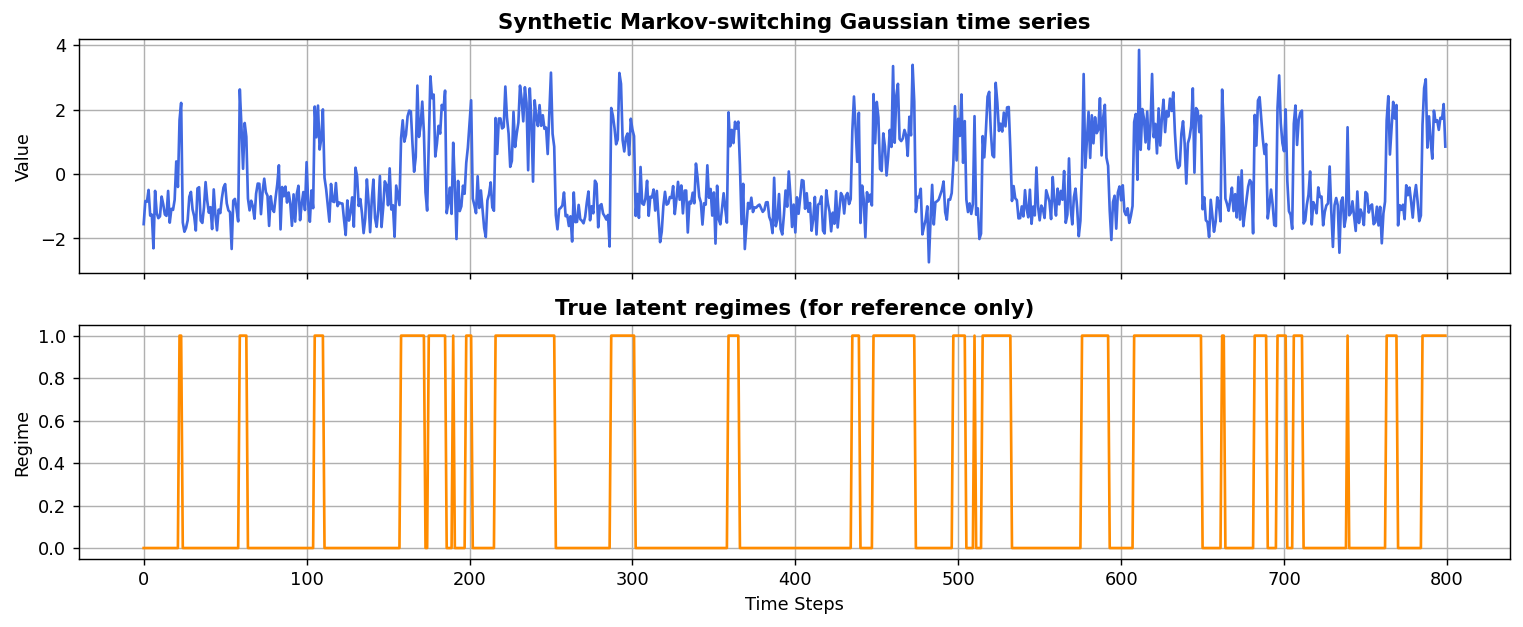

In [2]:
def generate_regime_switching_gaussian(
    seq_length: int = 800,
    transition: np.ndarray = None,
    random_state: int = 0,
) -> tuple:
    """Generate a simple two-regime Markov-switching Gaussian process for demonstration."""
    rng = np.random.RandomState(random_state)

    if transition is None:
        # transition[j, i] = P(S_t = j | S_{t-1} = i)
        transition = np.array([[0.95, 0.10], [0.05, 0.90]])

    const = np.array([-1.0, 1.5])
    sigma = np.array([0.50, 0.80])

    y = np.zeros(seq_length)
    regimes = np.zeros(seq_length, dtype=int)
    current_regime = rng.choice(2, p=[0.5, 0.5])
    y[0] = const[current_regime] + rng.normal(scale=sigma[current_regime])
    regimes[0] = current_regime

    for t in range(1, seq_length):
        current_regime = rng.choice(2, p=transition[:, current_regime])
        white_noise = rng.normal()
        y[t] = const[current_regime] + sigma[current_regime] * white_noise
        regimes[t] = current_regime

    return y, regimes


seq_length = 800
time_series, true_regimes = generate_regime_switching_gaussian(
    seq_length=seq_length, random_state=42
)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True, dpi=128)
ax[0].plot(time_series, color="royalblue")
ax[0].set_title("Synthetic Markov-switching Gaussian time series", fontweight="bold")
ax[0].set_ylabel("Value")
ax[0].grid(True)
ax[1].plot(true_regimes, color="darkorange")
ax[1].set_title("True latent regimes (for reference only)", fontweight="bold")
ax[1].set_xlabel("Time Steps")
ax[1].set_ylabel("Regime")
ax[1].grid(True)
plt.tight_layout()


## Step 2: Fit the Markov-switching Gaussian model manually with statsmodels

Before using the encapsulated simulator, we fit a `MarkovRegression` model with `order=0` directly to inspect the estimated component means, variances, and transition probabilities.


In [3]:
k_regimes = 2

mr_model = MarkovRegression(
    endog=time_series,
    k_regimes=k_regimes,
    order=0,
    trend="c",
    switching_trend=True,
    switching_variance=True,
)
mr_result = mr_model.fit(disp=False, maxiter=200)

print(mr_result.summary())
print("\nEstimated transition matrix (P[S_t=j | S_{t-1}=i]):")
print(mr_result.regime_transition[:, :, 0])

                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  800
Model:               MarkovRegression   Log Likelihood                -879.449
Date:                Sun, 21 Jun 2026   AIC                           1770.899
Time:                        23:15:17   BIC                           1799.006
Sample:                             0   HQIC                          1781.696
                                - 800                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0001      0.023    -44.109      0.000      -1.045      -0.956
sigma2         0.2659      0.017     15.684      0.0


## Step 3: Inspect smoothed regime probabilities

After fitting, the Kim smoother provides the posterior probability that each observation belongs to each regime. Persistent high/low segments in the time domain should align with regime probability mass concentrated on one component.


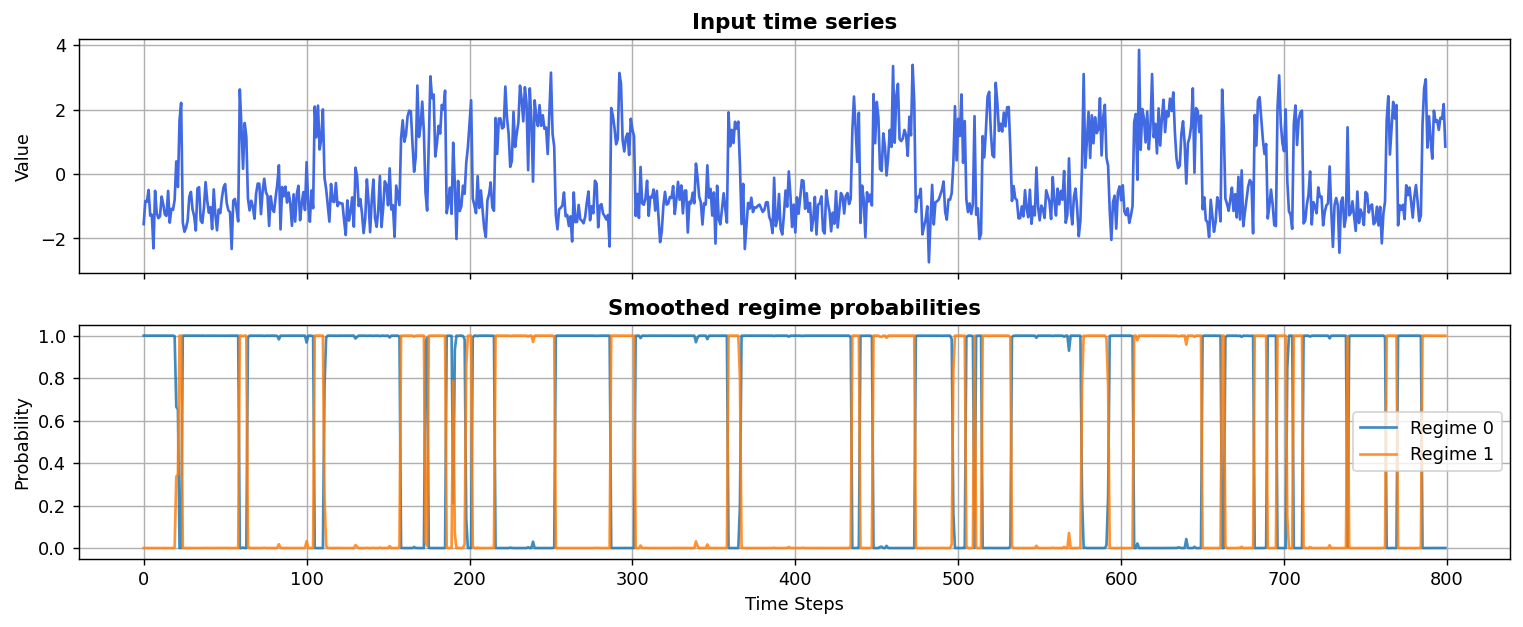

In [4]:
smoothed_probs = mr_result.smoothed_marginal_probabilities

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True, dpi=128)
ax[0].plot(time_series, color="royalblue")
ax[0].set_title("Input time series", fontweight="bold")
ax[0].set_ylabel("Value")
ax[0].grid(True)

for regime in range(k_regimes):
    ax[1].plot(
        smoothed_probs[:, regime],
        label=f"Regime {regime}",
        alpha=0.85,
    )
ax[1].set_title("Smoothed regime probabilities", fontweight="bold")
ax[1].set_xlabel("Time Steps")
ax[1].set_ylabel("Probability")
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()


## Step 4: Generate a new sequence from the fitted dynamics

We simulate a new path by drawing both a Markov regime sequence and regime-specific standard Gaussian white noise, then applying the emission equation $y_t = \mu_{S_t} + \sigma_{S_t} w_t$.


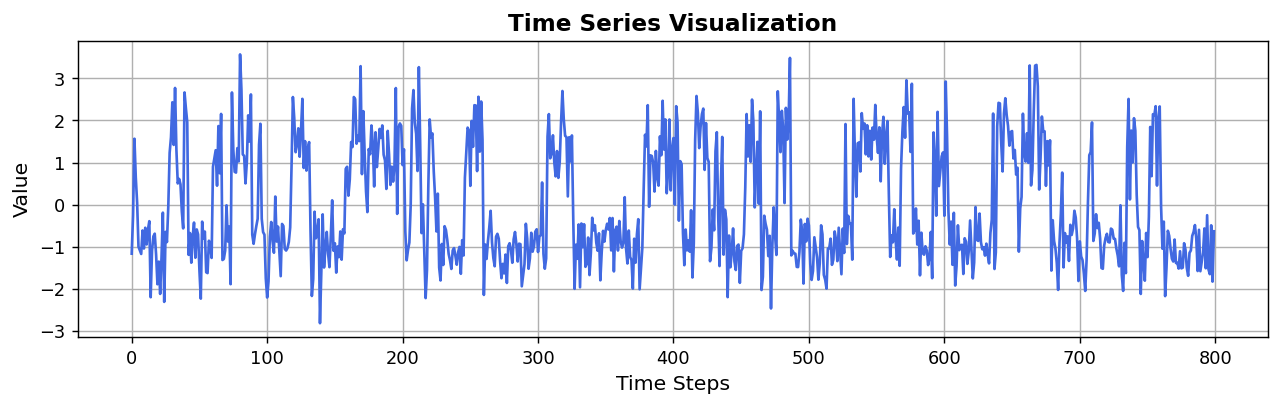

In [5]:
def simulate_markov_gaussian_path(result, seq_length, random_state=7):
    """Simulate one Markov-switching Gaussian sample path from a fitted result object."""
    rng = np.random.RandomState(random_state)
    k = result.k_regimes
    model = result.model
    params = result.params

    const = np.zeros(k)
    for regime in range(k):
        const[regime] = params[model.parameters[regime, "exog"]][0]

    variance = params[model.parameters["variance"]]
    variance = np.atleast_1d(variance)
    if variance.size == 1:
        variance = np.repeat(variance[0], k)

    transition = result.regime_transition[:, :, 0]
    current_regime = rng.choice(k, p=result.initial_probabilities)
    simulated = np.zeros(seq_length)

    for t in range(seq_length):
        if t > 0:
            current_regime = rng.choice(k, p=transition[:, current_regime])
        white_noise = rng.normal()
        simulated[t] = (
            const[current_regime] + np.sqrt(variance[current_regime]) * white_noise
        )

    return simulated


generated_series = simulate_markov_gaussian_path(
    mr_result, seq_length=seq_length, random_state=7
)
fig = plot_univariate_time_series(generated_series, dpi=128)


## Step 5: Statistical comparison

We compare the original and generated sequences in the time domain, marginal distribution, autocorrelation function, and power spectral density.


Text(0.5, 1.01, 'Manual Markov-switching Gaussian pipeline: original vs generated')

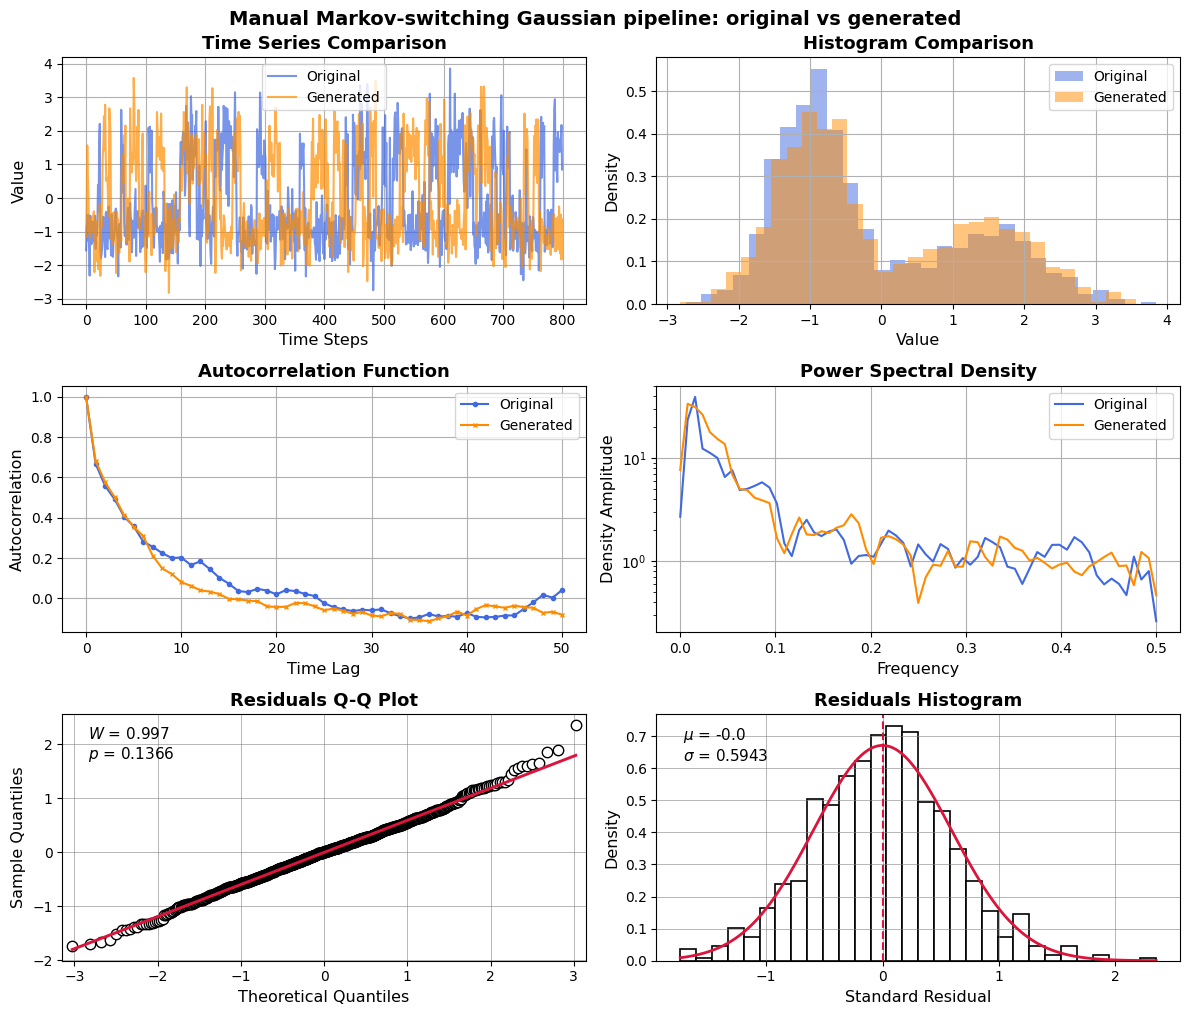

In [6]:
fig = plot_simulator_statistics(
    original_series=time_series,
    generated_series=generated_series,
    residuals=mr_result.resid,
)
fig.suptitle(
    "Manual Markov-switching Gaussian pipeline: original vs generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)


The generated sequence preserves the multi-modal marginal distribution and segment-like structure induced by regime switching. Because this model captures **regime-dependent means and variances** rather than a single global ARMA structure, it is often more appropriate for time series with changing level or volatility segments.

---

## Using `GaussianMixtureSimulator` in S2Generator

The entire pipeline above is encapsulated in the `GaussianMixtureSimulator` class. Its API is consistent with `ARIMASimulator`, `WienerFilterSimulator`, `KalmanFilterSimulator`, and `MarkovSwitchingSimulator`: call `fit` on the input series, then `transform` to generate new samples.


In [7]:
simulator = GaussianMixtureSimulator(
    n_components=2,
    switching_variance=True,
    revin=True,
    random_state=42,
    max_iter=200,
    not_white_alarm=False,
)

# Fit with automatic component-number selection via BIC
simulator.fit(time_series, select_order=True)

print("Fit summary")
print(f"  k_regimes : {simulator.k_regimes}")
print(f"  BIC       : {simulator.model.bic:.4f}")
print(f"  means     : {simulator.means()}")
print(f"  variances : {simulator.covariances()}")
print(f"  weights   : {simulator.weights()}")
print("\nTransition matrix:")
print(simulator.regime_transition[:, :, 0])

Fit summary
  k_regimes : 2
  BIC       : 1349.0702
  means     : [-0.62697315  1.25681825]
  variances : [0.15151851 0.33326846]
  weights   : [0.66447941 0.33552059]

Transition matrix:
[[0.95518627 0.08875103]
 [0.04481373 0.91124897]]


Generated batch shape: (5, 800)


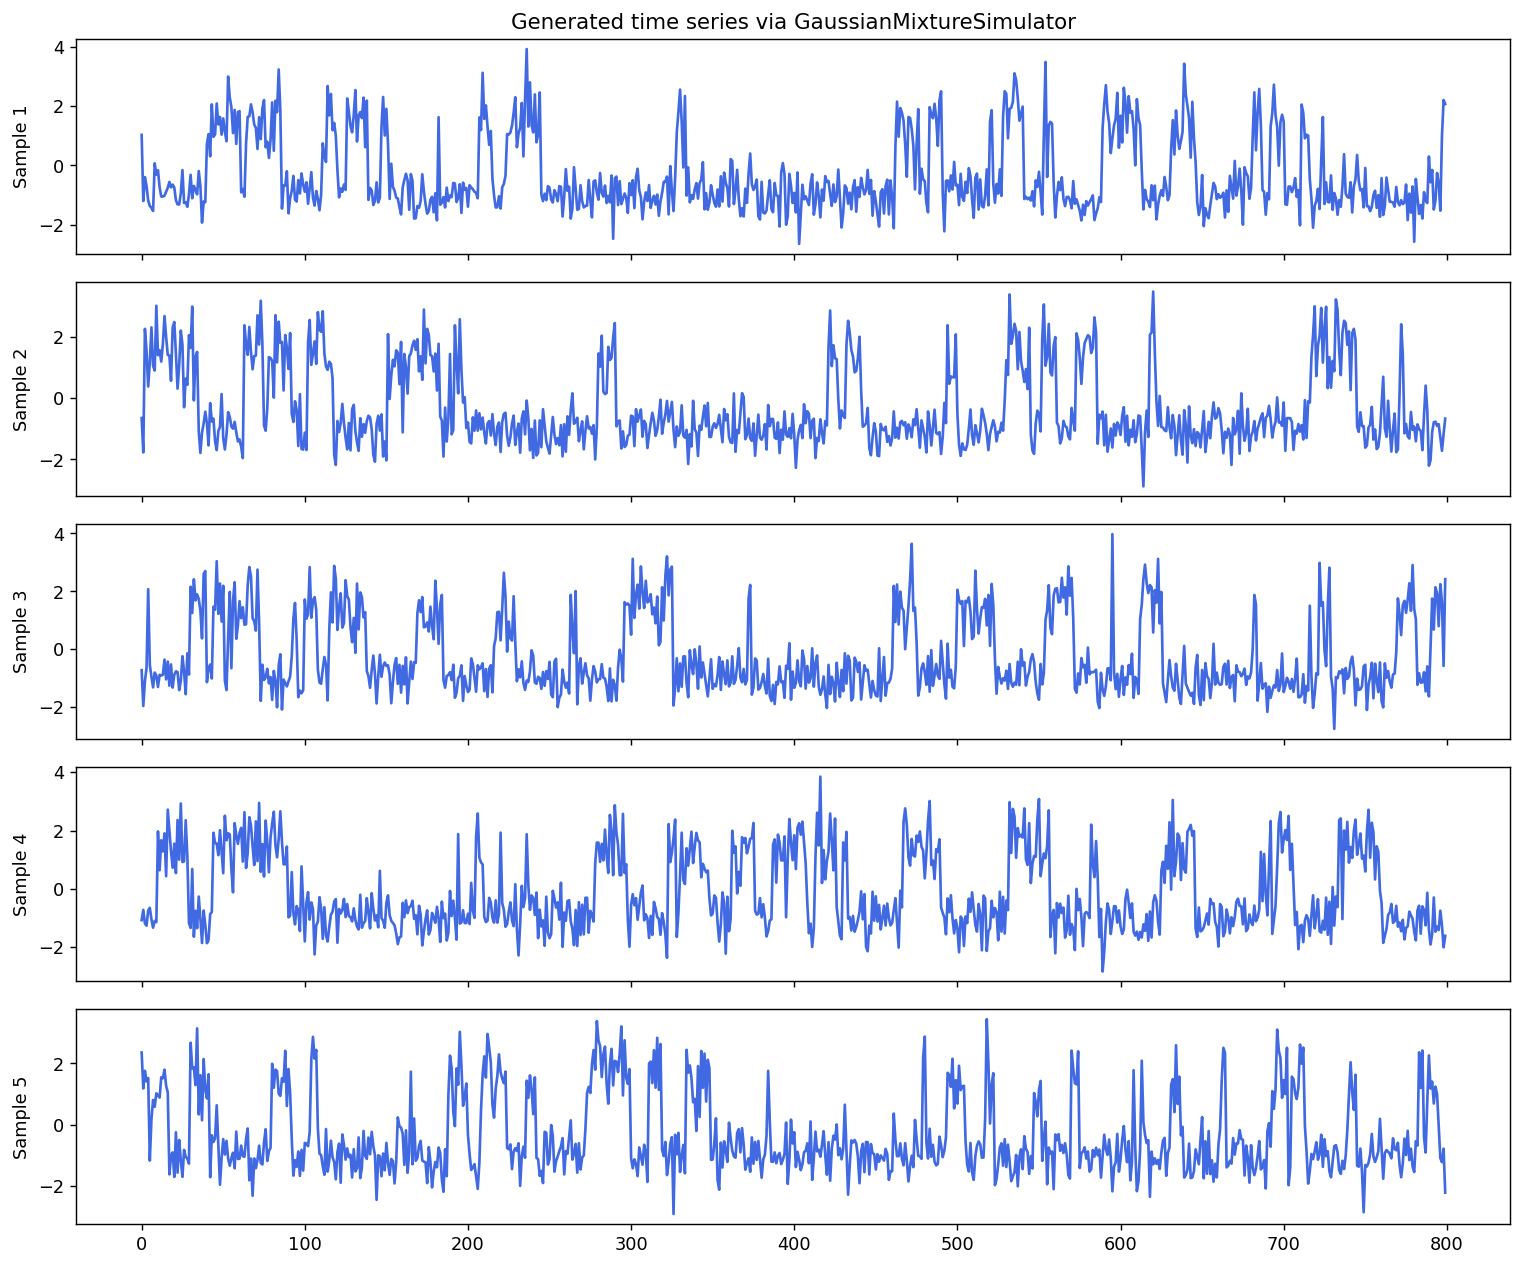

In [8]:
generated_batch = simulator.transform(
    num_samples=5,
    seq_length=seq_length,
    random_state=128,
)
print("Generated batch shape:", generated_batch.shape)

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True, dpi=128)
for i, series in enumerate(generated_batch):
    ax[i].plot(series, color="royalblue")
    ax[i].set_ylabel(f"Sample {i + 1}")
ax[0].set_title("Generated time series via GaussianMixtureSimulator")
plt.tight_layout()

Text(0.5, 1.01, 'GaussianMixtureSimulator: original vs generated')

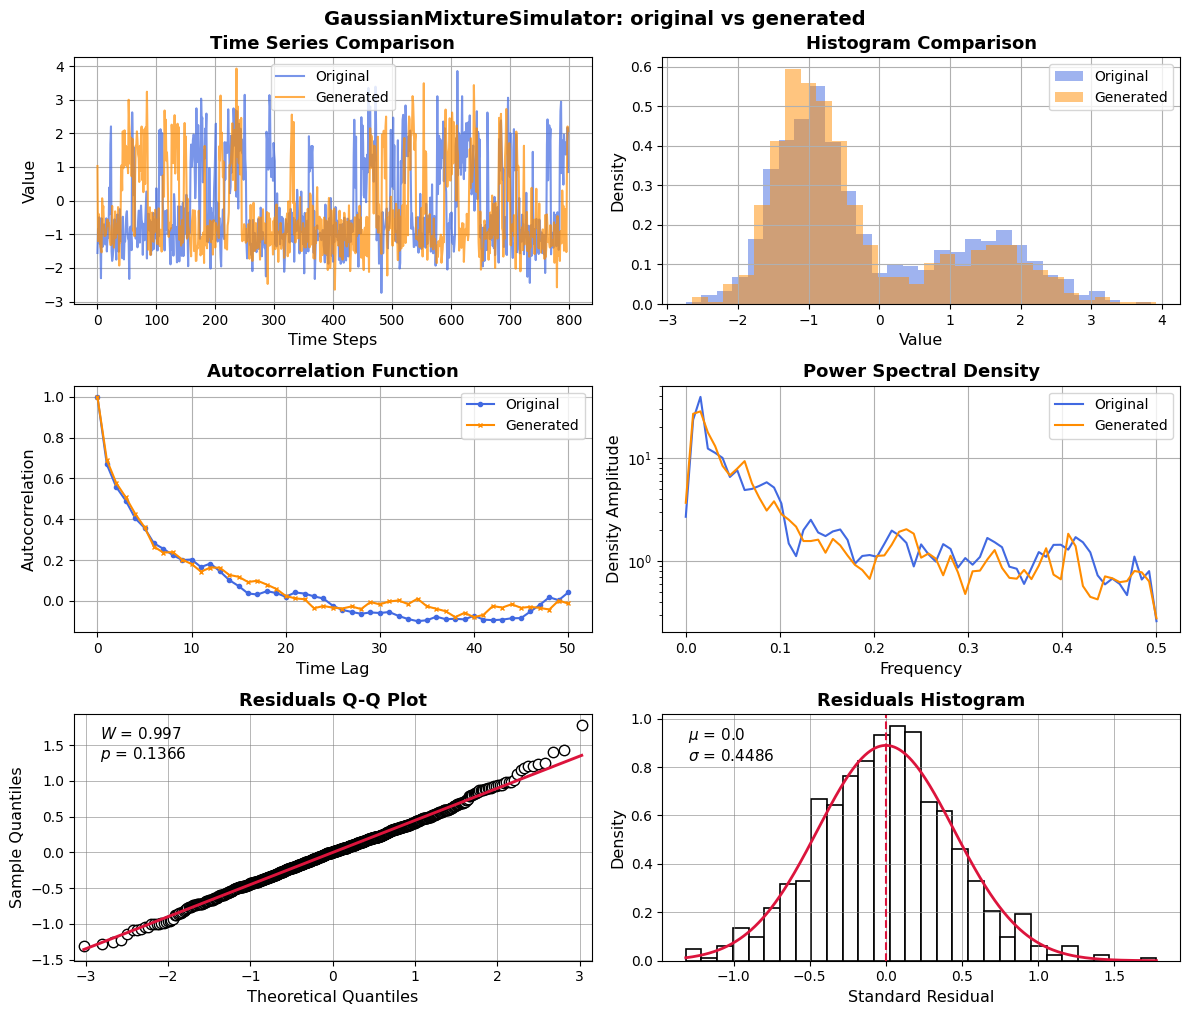

In [9]:
fig = plot_simulator_statistics(
    original_series=time_series,
    generated_series=generated_batch[0],
    residuals=simulator.residuals,
)
fig.suptitle(
    "GaussianMixtureSimulator: original vs generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)


### Supplementary demo: real spectrum data

The following cell applies the same workflow to a real spectrum sequence. Because this dataset is closer to a globally stationary AR-like process than to a piecewise mixture process, the Markov-switching Gaussian model may select fewer regimes; the example mainly demonstrates API usage on non-synthetic data.


Text(0.5, 1.01, 'GaussianMixtureSimulator on real spectrum data')

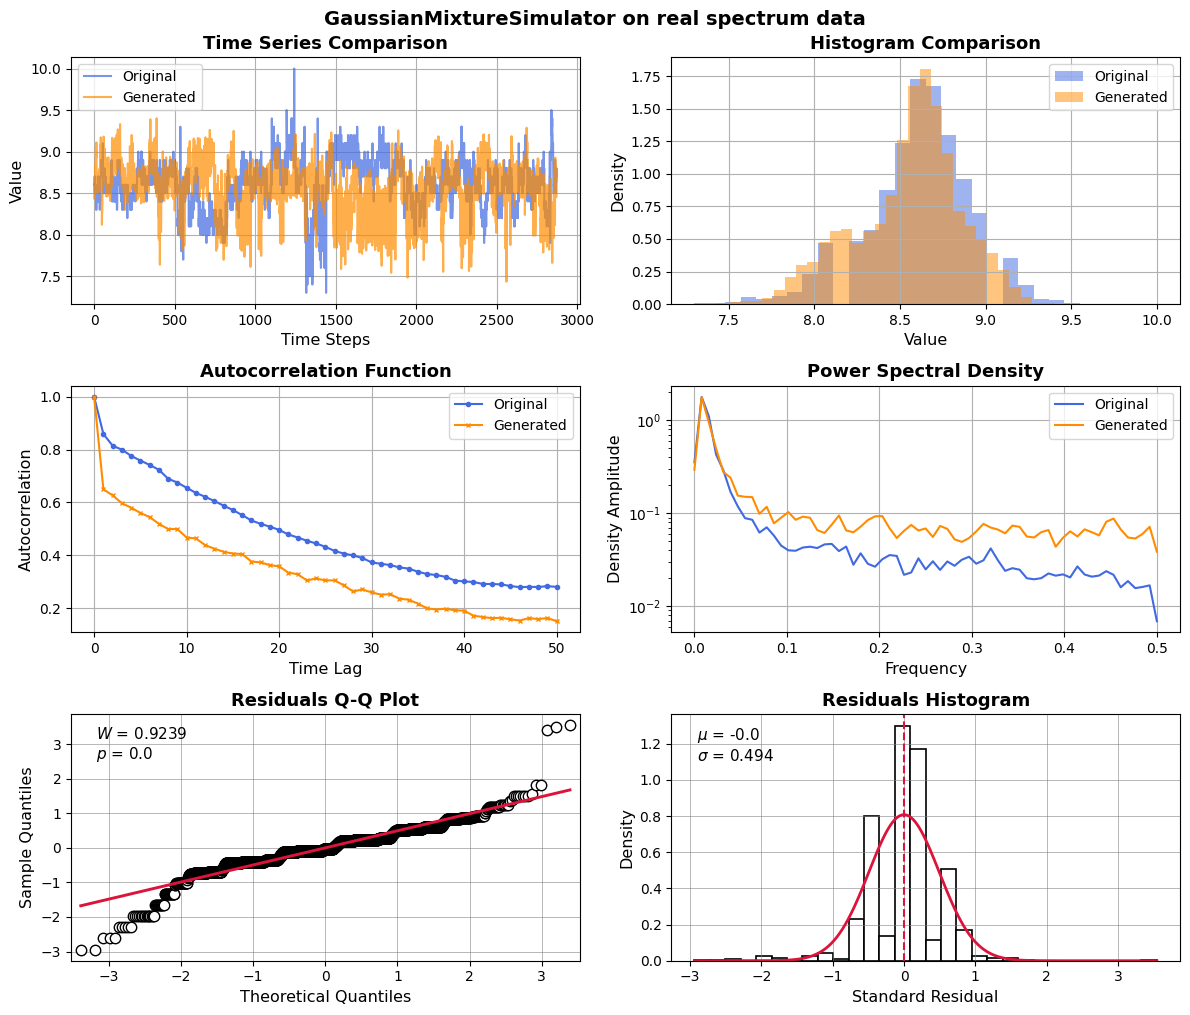

In [10]:
spectrum_series = np.load("..\\docs\\source\\_static\\spectrum.npy")

spectrum_simulator = GaussianMixtureSimulator(
    n_components=3,
    max_n_components=3,
    switching_variance=True,
    revin=True,
    random_state=0,
    max_iter=200,
    not_white_alarm=False,
)
spectrum_simulator.fit(spectrum_series, select_order=True)

spectrum_generated = spectrum_simulator.transform(
    num_samples=1,
    seq_length=len(spectrum_series),
    random_state=1,
)[0]

fig = plot_simulator_statistics(
    original_series=spectrum_series,
    generated_series=spectrum_generated,
    residuals=spectrum_simulator.residuals,
)
fig.suptitle(
    "GaussianMixtureSimulator on real spectrum data",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)